In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os

In [14]:
platforms = sorted(clean_df["platform"].unique())

label_map = {
    platform: idx
    for idx, platform in enumerate(platforms)
}

print(label_map)

{'Apple': 0, 'Facebook': 1, 'Google': 2, 'JoyPixels': 3, 'Samsung': 4, 'Twitter': 5, 'Windows': 6}


In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [9]:
import pandas as pd

train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/val.csv")
test_df = pd.read_csv("../data/processed/test.csv")

clean_df = pd.read_csv("../data/processed/clean_metadata.csv")

print(len(train_df))
print(len(val_df))
print(len(test_df))

8400
1800
1801


In [12]:
class EmojiDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = f"../data/processed/{row['platform']}/{row['file_name']}"

        image = Image.open(image_path).convert("RGB")

        label = label_map[row["platform"]]

        if self.transform:
            image = self.transform(image)

        return image, label

In [13]:
train_dataset = EmojiDataset(
    train_df,
    transform=transform
)

val_dataset = EmojiDataset(
    val_df,
    transform=transform
)

test_dataset = EmojiDataset(
    test_df,
    transform=transform
)

print(len(train_dataset))

8400


In [15]:
train_dataset = EmojiDataset(train_df, transform=transform)
val_dataset = EmojiDataset(val_df, transform=transform)
test_dataset = EmojiDataset(test_df, transform=transform)

print(len(train_dataset))

8400


In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels[:10])

torch.Size([32, 3, 224, 224])
tensor([1, 6, 4, 3, 1, 4, 5, 0, 4, 0])


C:\Users\chagitmi\AppData\Local\Programs\Python\Python314\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [27]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [28]:
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 263
Val batches: 57


In [17]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [29]:
model = models.resnet50(pretrained=True)

In [30]:
for param in model.parameters():
    param.requires_grad = False

In [31]:
num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    7
)

In [32]:
model = model.to(device)

In [33]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [34]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([32, 7])


In [35]:
def calculate_accuracy(outputs, labels):
    
    _, preds = torch.max(outputs, 1)

    correct = (preds == labels).sum().item()

    return correct / len(labels)

In [36]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

epochs = 3

In [37]:
for epoch in range(epochs):

    # TRAIN
    model.train()

    running_loss = 0
    running_acc = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        running_acc += calculate_accuracy(outputs, labels)


    train_loss = running_loss / len(train_loader)
    train_acc = running_acc / len(train_loader)


    # VALIDATION
    model.eval()

    val_running_loss = 0
    val_running_acc = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            val_running_acc += calculate_accuracy(
                outputs,
                labels
            )


    val_loss = val_running_loss / len(val_loader)
    val_acc = val_running_acc / len(val_loader)


    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)


    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/3 | Train Acc: 0.6652 | Val Acc: 0.7851
Epoch 2/3 | Train Acc: 0.7834 | Val Acc: 0.7741
Epoch 3/3 | Train Acc: 0.8083 | Val Acc: 0.8076


In [38]:
baseline_accuracy = val_accuracies[-1]

print(baseline_accuracy)

0.8075657894736842


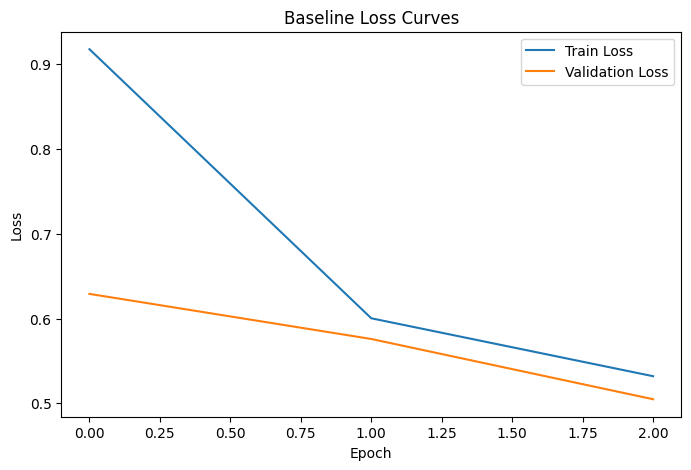

In [39]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.title("Baseline Loss Curves")

plt.show()

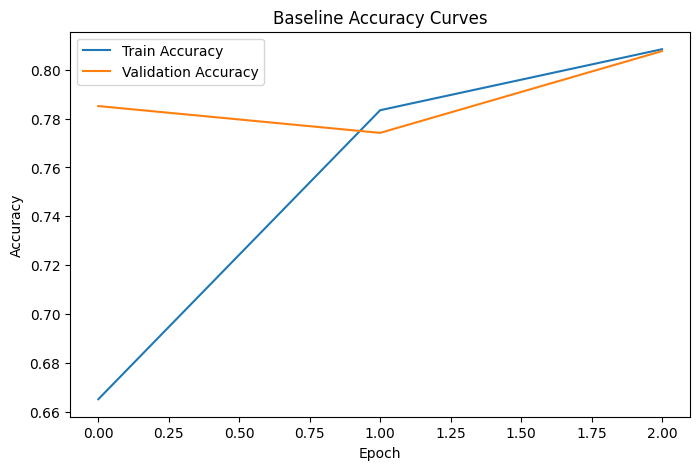

In [40]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.title("Baseline Accuracy Curves")

plt.show()

In [41]:
experiment_results = {
    "Baseline": baseline_accuracy
}

print(experiment_results)

{'Baseline': 0.8075657894736842}
